# Задача 1

Обучите модель u-net семантической сегментации на встроенном в torchvision датасете Pascal VOC с VGG в качестве энкодера

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import VOCSegmentation
from torchvision.models import vgg16_bn # Импортируем VGG16 с BatchNorm
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm # для прогресс-бара
import random

In [2]:
# Проверка и установка tqdm, если необходимо
try:
    from tqdm import tqdm
except ImportError:
    print("Installing tqdm...")
    !pip install tqdm -q
    from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
# --- Вспомогательные блоки (как в предыдущих примерах) ---
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UpConv(nn.Module):
    # Используем ConvTranspose2d для апсемплинга
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        return self.up(x)

# --- Модель VGG-UNet ---
class VGGUNet(nn.Module):
    def __init__(self, n_classes=21, pretrained=True): # 21 класс в Pascal VOC
        super().__init__()
        self.n_classes = n_classes

        # --- Энкодер (VGG16_bn features) ---
        vgg_features = vgg16_bn(weights='VGG16_BN_Weights.DEFAULT' if pretrained else None).features

        # Разделяем VGG на блоки для skip connections
        # Индексы соответствуют nn.Sequential в vgg_features
        self.block1 = nn.Sequential(*vgg_features[:6])    # Out: 64 channels, H, W (после conv, до pool)
        self.pool1 = vgg_features[6]                       # MaxPool2d -> H/2, W/2

        self.block2 = nn.Sequential(*vgg_features[7:13])  # Out: 128 channels, H/2, W/2
        self.pool2 = vgg_features[13]                      # MaxPool2d -> H/4, W/4

        self.block3 = nn.Sequential(*vgg_features[14:23]) # Out: 256 channels, H/4, W/4
        self.pool3 = vgg_features[23]                      # MaxPool2d -> H/8, W/8

        self.block4 = nn.Sequential(*vgg_features[24:33]) # Out: 512 channels, H/8, W/8
        self.pool4 = vgg_features[33]                      # MaxPool2d -> H/16, W/16

        self.block5 = nn.Sequential(*vgg_features[34:43]) # Out: 512 channels, H/16, W/16
        self.pool5 = vgg_features[43]                      # MaxPool2d -> H/32, W/32 (Bottleneck input)

        # --- Bottleneck ---
        # Можно добавить дополнительные свертки здесь, но для простоты используем block5 как вход
        self.bottleneck = self.pool5 # Просто последний MaxPool

        # --- Декодер ---
        # Каналы после каждого блока энкодера (до пулинга) для skip:
        # block1: 64, block2: 128, block3: 256, block4: 512, block5: 512

        # Up 1 (из bottleneck/block5)
        self.upconv1 = UpConv(512, 512) # H/16, W/16
        # Skip connection из block4 (512)
        self.decoder1 = DoubleConv(512 + 512, 512) # Concat -> 1024 channels

        # Up 2
        self.upconv2 = UpConv(512, 256) # H/8, W/8
        # Skip connection из block3 (256)
        self.decoder2 = DoubleConv(256 + 256, 256) # Concat -> 512 channels

        # Up 3
        self.upconv3 = UpConv(256, 128) # H/4, W/4
        # Skip connection из block2 (128)
        self.decoder3 = DoubleConv(128 + 128, 128) # Concat -> 256 channels

        # Up 4
        self.upconv4 = UpConv(128, 64)  # H/2, W/2
        # Skip connection из block1 (64)
        self.decoder4 = DoubleConv(64 + 64, 64)   # Concat -> 128 channels

        # --- Финальный слой ---
        # Финальная свертка 1x1 для получения нужного количества классов
        self.final_conv = nn.Conv2d(64, n_classes, kernel_size=1)


    def forward(self, x):
        # --- Энкодер ---
        # print("Input:", x.shape)
        s1 = self.block1(x)     # H, W, 64
        p1 = self.pool1(s1)    # H/2, W/2, 64
        # print("s1:", s1.shape, "p1:", p1.shape)

        s2 = self.block2(p1)    # H/2, W/2, 128
        p2 = self.pool2(s2)    # H/4, W/4, 128
        # print("s2:", s2.shape, "p2:", p2.shape)

        s3 = self.block3(p2)    # H/4, W/4, 256
        p3 = self.pool3(s3)    # H/8, W/8, 256
        # print("s3:", s3.shape, "p3:", p3.shape)

        s4 = self.block4(p3)    # H/8, W/8, 512
        p4 = self.pool4(s4)    # H/16, W/16, 512
        # print("s4:", s4.shape, "p4:", p4.shape)

        s5 = self.block5(p4)    # H/16, W/16, 512
        # bottleneck = self.pool5(s5) # H/32, W/32, 512 - не используем в этой версии
        # print("s5:", s5.shape)

        # --- Декодер ---
        d1 = self.upconv1(s5) # Используем выход block5 как вход в декодер
        # print("d1(up):", d1.shape, "s4(skip):", s4.shape)
        d1 = torch.cat([d1, s4], dim=1)
        d1 = self.decoder1(d1)
        # print("d1(conv):", d1.shape)

        d2 = self.upconv2(d1)
        # print("d2(up):", d2.shape, "s3(skip):", s3.shape)
        d2 = torch.cat([d2, s3], dim=1)
        d2 = self.decoder2(d2)
        # print("d2(conv):", d2.shape)

        d3 = self.upconv3(d2)
        # print("d3(up):", d3.shape, "s2(skip):", s2.shape)
        d3 = torch.cat([d3, s2], dim=1)
        d3 = self.decoder3(d3)
        # print("d3(conv):", d3.shape)

        d4 = self.upconv4(d3)
        # print("d4(up):", d4.shape, "s1(skip):", s1.shape)
        d4 = torch.cat([d4, s1], dim=1)
        d4 = self.decoder4(d4)
        # print("d4(conv):", d4.shape)

        # --- Финальный выход ---
        # print("Final Up:", out.shape)
        logits = self.final_conv(d4)
        # print("Logits:", logits.shape)

        return logits

In [7]:
# --- Параметры ---
DATA_ROOT = './pascal_voc' # Директория для скачивания/хранения датасета
IMG_SIZE = (256, 256) # Уменьшаем размер для ускорения/экономии памяти
BATCH_SIZE = 8        # Уменьшите, если не хватает памяти GPU
NUM_CLASSES = 21      # 20 классов + 1 фон в Pascal VOC
IGNORE_INDEX = 255    # Индекс для игнорируемых пикселей (границы объектов)

# --- Трансформации ---
# ImageNet статистика для нормализации (т.к. VGG предобучен на ImageNet)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Трансформации для изображений
transform_img = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Трансформации ТОЛЬКО для масок
# Важно: НЕ нормализуем маски, используем NEAREST интерполяцию
transform_mask = transforms.Compose([
    transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor() # Конвертирует PIL [H, W, C] или [H, W] в Tensor [C, H, W] или [H,W]
    # transforms.Lambda(lambda x: x.squeeze().long()) # Убираем размерность канала и конвертируем в Long
])

# Небольшая обертка для правильной обработки маски после стандартного transform_mask
def target_transform_wrapper(mask_tensor):
    # PILToTensor может вернуть [1, H, W], убираем канал
    # Также конвертируем в Long для CrossEntropyLoss
    return mask_tensor.squeeze(0).long()

# --- Загрузка Датасета ---
try:
    train_dataset = VOCSegmentation(root=DATA_ROOT, year='2012', image_set='train',
                                    download=True, transform=transform_img,
                                    target_transform=lambda mask: target_transform_wrapper(transform_mask(mask)))

    val_dataset = VOCSegmentation(root=DATA_ROOT, year='2012', image_set='val',
                                  download=True, transform=transform_img,
                                  target_transform=lambda mask: target_transform_wrapper(transform_mask(mask)))

    print(f"Pascal VOC dataset loaded successfully.")
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Validation dataset size: {len(val_dataset)}")

except Exception as e:
    print(f"Error loading Pascal VOC dataset: {e}")
    print("Please check your internet connection or storage space.")
    # Остановить выполнение, если датасет не загружен
    raise

# --- Создание Загрузчиков ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Проверка одного батча
try:
    images, masks = next(iter(train_loader))
    print("Sample batch - Image shape:", images.shape) # Ожидаем [Batch, 3, H, W]
    print("Sample batch - Mask shape:", masks.shape)   # Ожидаем [Batch, H, W]
    print("Sample batch - Mask dtype:", masks.dtype)   # Ожидаем torch.int64 (Long)
    print("Sample batch - Mask unique values:", torch.unique(masks)) # Посмотреть классы в маске
except Exception as e:
     print(f"Error iterating dataloader: {e}")
     print("Check dataset integrity and transformations.")
     raise

Pascal VOC dataset loaded successfully.
Train dataset size: 1464
Validation dataset size: 1449
Sample batch - Image shape: torch.Size([8, 3, 256, 256])
Sample batch - Mask shape: torch.Size([8, 256, 256])
Sample batch - Mask dtype: torch.int64
Sample batch - Mask unique values: tensor([  0,   2,   5,   6,   8,   9,  11,  15, 255])


Starting Training...


Validation Epoch 1/5: 100%|██████████| 182/182 [00:33<00:00,  5.37it/s, loss=2.3360]


Epoch 1: Train Loss: 2.0536, Val Loss: 1.7690


Validation Epoch 2/5: 100%|██████████| 182/182 [00:33<00:00,  5.44it/s, loss=2.2825]


Epoch 2: Train Loss: 1.4381, Val Loss: 1.3676


...

Epoch 3: Train Loss: 1.1119, Val Loss: 0.9939


Validation Epoch 4/5: 100%|██████████| 182/182 [00:33<00:00,  5.42it/s, loss=2.4940]


Epoch 4: Train Loss: 0.9288, Val Loss: 0.9317


Validation Epoch 5/5: 100%|██████████| 182/182 [00:33<00:00,  5.42it/s, loss=2.5722]


Epoch 5: Train Loss: 0.8020, Val Loss: 0.8312
Training Finished!


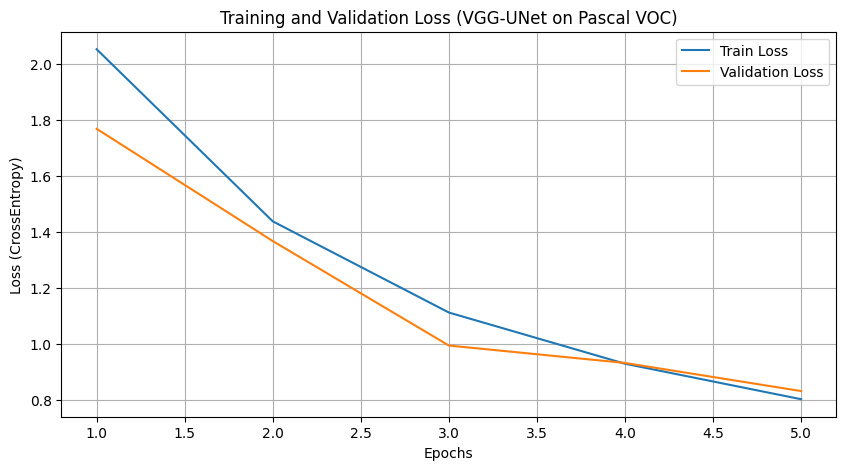

In [10]:
# --- Параметры обучения ---
LEARNING_RATE = 1e-4
NUM_EPOCHS = 5 # Для демонстрации, для хорошего результата нужно больше (50+)

# --- Инициализация Модели, Функции Потерь и Оптимизатора ---
model = VGGUNet(n_classes=NUM_CLASSES, pretrained=True).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX) # Игнорируем границы
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- Функции для цикла обучения и валидации (похожи на предыдущие) ---
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    pbar = tqdm(loader, desc=f"Training Epoch {epoch+1}/{NUM_EPOCHS}")
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device) # [N, H, W], LongTensor

        optimizer.zero_grad()
        outputs = model(images) # [N, C, H, W]

        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    pbar = tqdm(loader, desc=f"Validation Epoch {epoch+1}/{NUM_EPOCHS}")
    with torch.no_grad():
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item() * images.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

# --- Цикл Обучения ---
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Starting Training...")
for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Сохранение лучшей модели
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # torch.save(model.state_dict(), 'vgg_unet_pascal_best.pth')
        # print(f"Model improved and saved to vgg_unet_pascal_best.pth")

print("Training Finished!")

# --- Визуализация потерь ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (CrossEntropy)')
plt.title('Training and Validation Loss (VGG-UNet on Pascal VOC)')
plt.legend()
plt.grid(True)
plt.show()


Visualizing results on validation set...


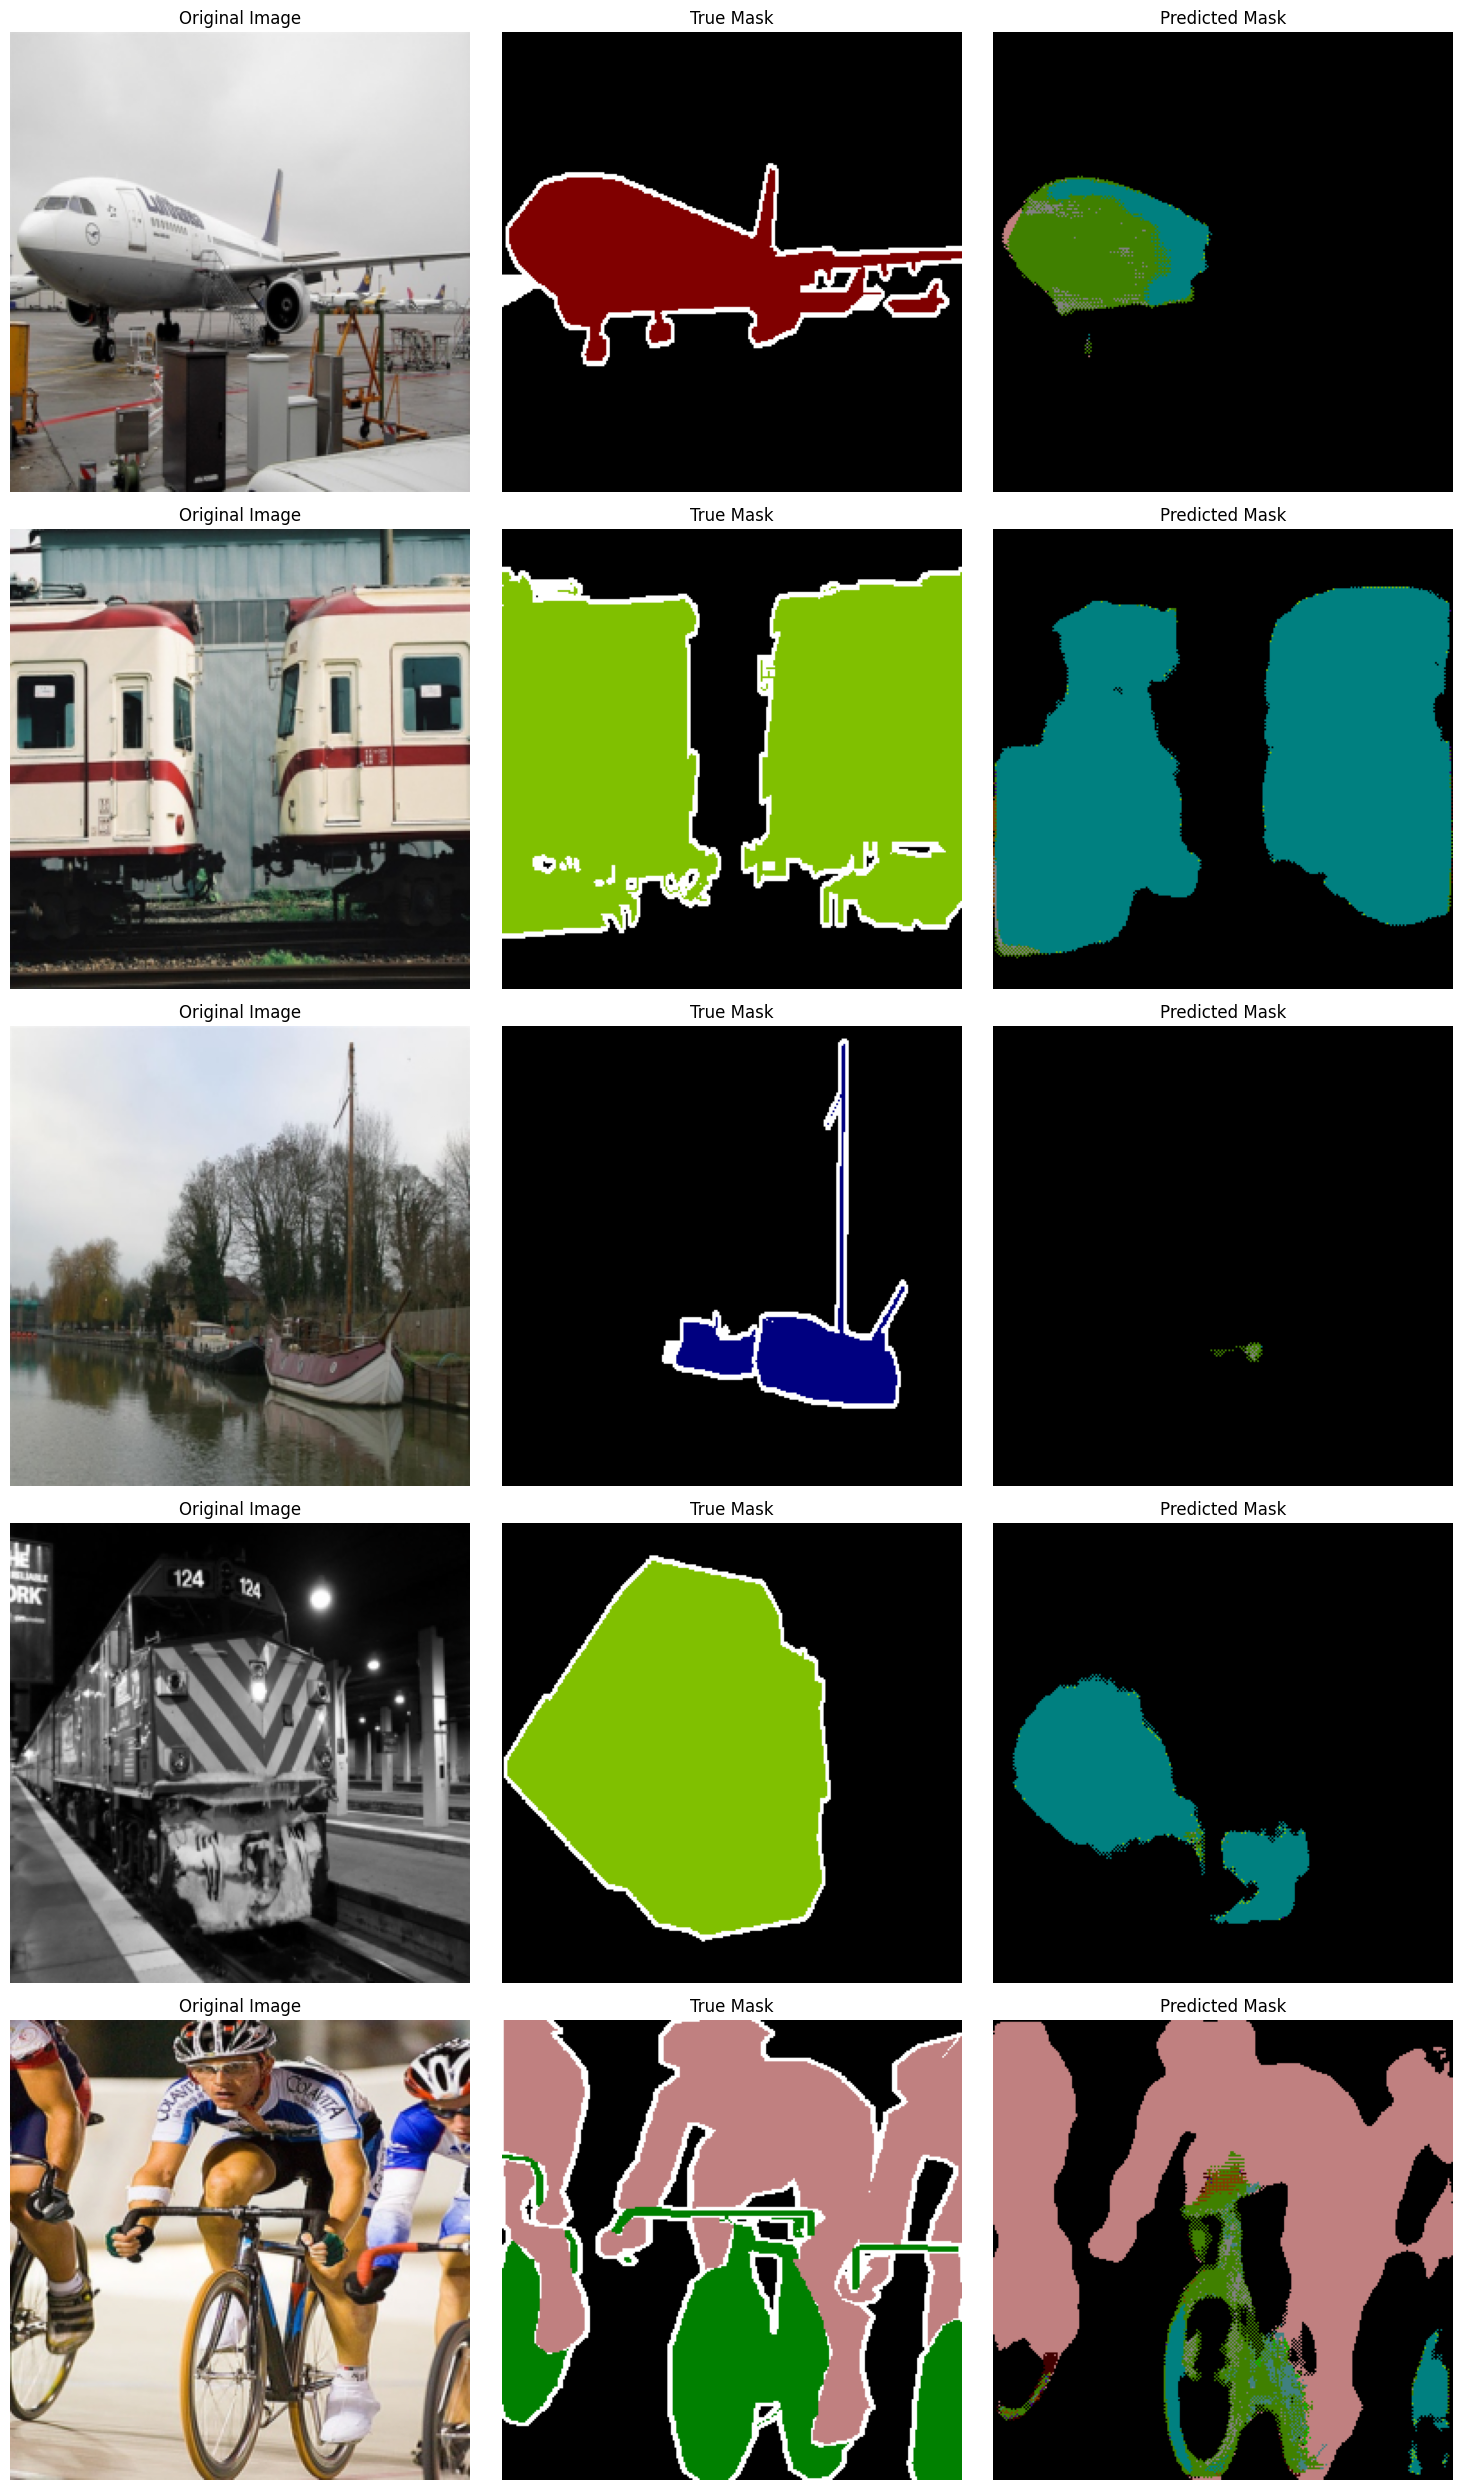

In [11]:
# --- Функция для визуализации ---
voc_colormap = np.array([
    [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128],
    [128, 0, 128], [0, 128, 128], [128, 128, 128], [64, 0, 0], [192, 0, 0],
    [64, 128, 0], [192, 128, 0], [64, 0, 128], [192, 0, 128], [64, 128, 128],
    [192, 128, 128], [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
    [0, 64, 128] # , [224, 224, 192] # Класс 21 (часто void/border)
], dtype=np.uint8)

# Добавим цвет для ignore_index (255), например, белый
full_colormap = np.zeros((256, 3), dtype=np.uint8)
full_colormap[:len(voc_colormap)] = voc_colormap
full_colormap[IGNORE_INDEX] = [255, 255, 255] # Белый для игнорируемых пикселей

def denormalize(tensor, mean, std):
    # Клонируем тензор, чтобы не изменять оригинал
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    # Обрезаем значения до [0, 1]
    tensor = torch.clamp(tensor, 0, 1)
    return tensor

def visualize_predictions(model, dataloader, device, num_samples=5):
    model.eval()
    samples_shown = 0
    # Используем iter, чтобы можно было прервать цикл
    data_iter = iter(dataloader)

    plt.figure(figsize=(15, num_samples * 5))

    with torch.no_grad():
        while samples_shown < num_samples:
            try:
                images, true_masks = next(data_iter)
            except StopIteration:
                print("Reached end of dataloader before showing enough samples.")
                break # Выход из цикла, если данные закончились

            images = images.to(device)
            outputs = model(images) # [N, C, H, W]
            preds = torch.argmax(outputs, dim=1).cpu() # [N, H, W]

            # Переносим все на CPU для визуализации
            images_cpu = images.cpu()
            true_masks_cpu = true_masks.cpu() # Уже на CPU, если dataloader без pin_memory

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    break

                img = images_cpu[i]
                true_mask = true_masks_cpu[i].numpy() # [H, W]
                pred_mask = preds[i].numpy()         # [H, W]

                # Денормализация изображения
                img_denorm = denormalize(img, imagenet_mean, imagenet_std)
                img_np = img_denorm.permute(1, 2, 0).numpy() # [H, W, 3]

                # Конвертация масок в RGB
                true_mask_rgb = full_colormap[true_mask]
                pred_mask_rgb = full_colormap[pred_mask]

                # Отображение
                plt.subplot(num_samples, 3, samples_shown * 3 + 1)
                plt.imshow(img_np)
                plt.title("Original Image")
                plt.axis('off')

                plt.subplot(num_samples, 3, samples_shown * 3 + 2)
                plt.imshow(true_mask_rgb)
                plt.title("True Mask")
                plt.axis('off')

                plt.subplot(num_samples, 3, samples_shown * 3 + 3)
                plt.imshow(pred_mask_rgb)
                plt.title("Predicted Mask")
                plt.axis('off')

                samples_shown += 1

    plt.tight_layout()
    plt.show()

# --- Запуск Визуализации ---
print("\nVisualizing results on validation set...")
# Загружаем лучшую модель, если сохраняли
# model.load_state_dict(torch.load('vgg_unet_pascal_best.pth'))
# model.to(device) # Убедимся, что модель на нужном устройстве
visualize_predictions(model, val_loader, device, num_samples=5)

# Задача 2

Обучите модель u-net семантической сегментации на встроенном в torchvision датасете Pascal VOC с ResNet в качестве энкодера

In [12]:
# --- Вспомогательные блоки  ---
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UpConv(nn.Module):
    # Используем ConvTranspose2d для апсемплинга
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        return self.up(x)

In [13]:
class ResNetUNet(nn.Module):
    def __init__(self, n_classes=21, pretrained=True): # 21 класс в Pascal VOC
        super().__init__()
        self.n_classes = n_classes

        # --- Энкодер (ResNet34) ---
        resnet = resnet34(weights='ResNet34_Weights.DEFAULT' if pretrained else None)

        # Начальный блок ResNet
        self.init_conv = nn.Sequential(
            resnet.conv1,    # H/2, W/2, 64 channels
            resnet.bn1,
            resnet.relu
        )
        self.init_pool = resnet.maxpool # H/4, W/4, 64 channels

        # Слои ResNet (блоки residual)
        self.encoder1 = resnet.layer1 # H/4, W/4, 64 channels
        self.encoder2 = resnet.layer2 # H/8, W/8, 128 channels
        self.encoder3 = resnet.layer3 # H/16, W/16, 256 channels
        self.encoder4 = resnet.layer4 # H/32, W/32, 512 channels (Bottleneck input)

        # --- Декодер ---
        # Каналы после каждого слоя энкодера (для skip connections):
        # init_conv: 64 (H/2), encoder1: 64 (H/4), encoder2: 128 (H/8),
        # encoder3: 256 (H/16), encoder4: 512 (H/32)

        # Up 1 (из encoder4 - H/32) -> H/16
        self.upconv1 = UpConv(512, 256)
        # Skip connection из encoder3 (256, H/16)
        self.decoder1 = DoubleConv(256 + 256, 256) # Concat -> 512 channels

        # Up 2 (из decoder1 - H/16) -> H/8
        self.upconv2 = UpConv(256, 128)
        # Skip connection из encoder2 (128, H/8)
        self.decoder2 = DoubleConv(128 + 128, 128) # Concat -> 256 channels

        # Up 3 (из decoder2 - H/8) -> H/4
        self.upconv3 = UpConv(128, 64)
        # Skip connection из encoder1 (64, H/4)
        self.decoder3 = DoubleConv(64 + 64, 64)   # Concat -> 128 channels

        # Up 4 (из decoder3 - H/4) -> H/2
        self.upconv4 = UpConv(64, 64)
        # Skip connection из init_conv (64, H/2)
        self.decoder4 = DoubleConv(64 + 64, 64)   # Concat -> 128 channels

        # --- Финальный слой ---
        # Еще один апсемплинг, чтобы вернуться к исходному размеру H, W
        self.final_up = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2) # H, W, 32 channels
        # Финальная свертка 1x1 для получения нужного количества классов
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1) # H, W, n_classes


    def forward(self, x):
        # --- Энкодер ---
        # print("Input:", x.shape)                  # H, W
        x_init = self.init_conv(x)     # H/2, W/2, 64
        x_pool = self.init_pool(x_init) # H/4, W/4, 64
        # print("x_init:", x_init.shape)
        # print("x_pool:", x_pool.shape)

        e1 = self.encoder1(x_pool)     # H/4, W/4, 64
        e2 = self.encoder2(e1)         # H/8, W/8, 128
        e3 = self.encoder3(e2)         # H/16, W/16, 256
        e4 = self.encoder4(e3)         # H/32, W/32, 512 (Bottleneck)
        # print("e1:", e1.shape)
        # print("e2:", e2.shape)
        # print("e3:", e3.shape)
        # print("e4:", e4.shape)

        # --- Декодер ---
        # print("Bottleneck(e4):", e4.shape)
        d1 = self.upconv1(e4)          # H/16, W/16, 256
        # print("d1(up):", d1.shape, "e3(skip):", e3.shape)
        d1 = torch.cat([d1, e3], dim=1) # Concat 256 + 256 = 512
        d1 = self.decoder1(d1)         # H/16, W/16, 256
        # print("d1(conv):", d1.shape)

        d2 = self.upconv2(d1)          # H/8, W/8, 128
        # print("d2(up):", d2.shape, "e2(skip):", e2.shape)
        d2 = torch.cat([d2, e2], dim=1) # Concat 128 + 128 = 256
        d2 = self.decoder2(d2)         # H/8, W/8, 128
        # print("d2(conv):", d2.shape)

        d3 = self.upconv3(d2)          # H/4, W/4, 64
        # print("d3(up):", d3.shape, "e1(skip):", e1.shape)
        d3 = torch.cat([d3, e1], dim=1) # Concat 64 + 64 = 128
        d3 = self.decoder3(d3)         # H/4, W/4, 64
        # print("d3(conv):", d3.shape)

        d4 = self.upconv4(d3)          # H/2, W/2, 64
        # print("d4(up):", d4.shape, "x_init(skip):", x_init.shape)
        d4 = torch.cat([d4, x_init], dim=1) # Concat 64 + 64 = 128
        d4 = self.decoder4(d4)         # H/2, W/2, 64
        # print("d4(conv):", d4.shape)

        # --- Финальный выход ---
        out = self.final_up(d4)        # H, W, 32
        # print("Final Up:", out.shape)
        logits = self.final_conv(out)  # H, W, n_classes
        # print("Logits:", logits.shape)

        return logits

In [14]:
# --- Параметры ---
DATA_ROOT = './pascal_voc' # Директория для скачивания/хранения датасета
IMG_SIZE = (256, 256) # Уменьшаем размер для ускорения/экономии памяти
BATCH_SIZE = 8        # Уменьшите, если не хватает памяти GPU
NUM_CLASSES = 21      # 20 классов + 1 фон в Pascal VOC
IGNORE_INDEX = 255    # Индекс для игнорируемых пикселей (границы объектов)

# --- Трансформации ---
# ImageNet статистика для нормализации (ResNet предобучен на ImageNet)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Трансформации для изображений
transform_img = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Трансформации ТОЛЬКО для масок
transform_mask = transforms.Compose([
    transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.NEAREST),
    transforms.PILToTensor()
])

# Обертка для правильной обработки маски
def target_transform_wrapper(mask_tensor):
    return mask_tensor.squeeze(0).long()

# --- Загрузка Датасета ---
try:
    train_dataset = VOCSegmentation(root=DATA_ROOT, year='2012', image_set='train',
                                    download=True, transform=transform_img,
                                    target_transform=lambda mask: target_transform_wrapper(transform_mask(mask)))

    val_dataset = VOCSegmentation(root=DATA_ROOT, year='2012', image_set='val',
                                  download=True, transform=transform_img,
                                  target_transform=lambda mask: target_transform_wrapper(transform_mask(mask)))

    print(f"Pascal VOC dataset loaded successfully.")
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Validation dataset size: {len(val_dataset)}")

except Exception as e:
    print(f"Error loading Pascal VOC dataset: {e}")
    raise

# --- Создание Загрузчиков ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Проверка одного батча
try:
    images, masks = next(iter(train_loader))
    print("Sample batch - Image shape:", images.shape)
    print("Sample batch - Mask shape:", masks.shape)
    print("Sample batch - Mask dtype:", masks.dtype)
    print("Sample batch - Mask unique values:", torch.unique(masks))
except Exception as e:
     print(f"Error iterating dataloader: {e}")
     raise

Pascal VOC dataset loaded successfully.
Train dataset size: 1464
Validation dataset size: 1449
Sample batch - Image shape: torch.Size([8, 3, 256, 256])
Sample batch - Mask shape: torch.Size([8, 256, 256])
Sample batch - Mask dtype: torch.int64
Sample batch - Mask unique values: tensor([  0,   4,   8,  13,  15,  17,  19,  20, 255])


In [16]:
from torchvision.models import resnet34 # Импортируем ResNet34


Starting Training ResNet-UNet...


Validation Epoch 1/12: 100%|██████████| 182/182 [00:13<00:00, 13.95it/s, loss=2.3076]


Epoch 1: Train Loss: 2.2925, Val Loss: 1.5784


Validation Epoch 2/12: 100%|██████████| 182/182 [00:13<00:00, 13.83it/s, loss=2.0980]


Epoch 2: Train Loss: 1.1948, Val Loss: 1.0893


...

Epoch 10: Train Loss: 0.7240, Val Loss: 0.9267


Validation Epoch 11/12: 100%|██████████| 182/182 [00:13<00:00, 13.94it/s, loss=2.3352]


Epoch 11: Train Loss: 0.7000, Val Loss: 0.9097


Validation Epoch 12/12: 100%|██████████| 182/182 [00:13<00:00, 13.52it/s, loss=2.3395]


Epoch 12: Train Loss: 0.7005, Val Loss: 0.8757
Training Finished!


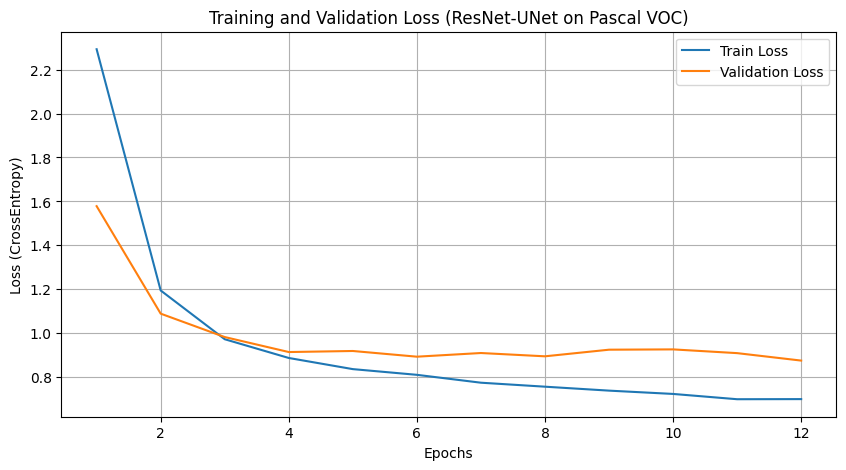

In [ ]:
# --- Параметры обучения ---
LEARNING_RATE = 1e-4
NUM_EPOCHS = 12 # Для демонстрации, для хорошего результата нужно больше

# --- Инициализация Модели, Функции Потерь и Оптимизатора ---
# Заменяем VGGUNet на ResNetUNet
model = ResNetUNet(n_classes=NUM_CLASSES, pretrained=True).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX) # Игнорируем границы
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- Функции для цикла обучения и валидации (без изменений) ---
def train_one_epoch(model, loader, optimizer, criterion, device, epoch, num_epochs):
    model.train()
    running_loss = 0.0
    pbar = tqdm(loader, desc=f"Training Epoch {epoch+1}/{num_epochs}")
    for images, masks in pbar:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

def validate_one_epoch(model, loader, criterion, device, epoch, num_epochs):
    model.eval()
    running_loss = 0.0
    pbar = tqdm(loader, desc=f"Validation Epoch {epoch+1}/{num_epochs}")
    with torch.no_grad():
        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item() * images.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

# --- Цикл Обучения ---
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Starting Training ResNet-UNet...")
for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch, NUM_EPOCHS)
    val_loss = validate_one_epoch(model, val_loader, criterion, device, epoch, NUM_EPOCHS)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # Сохранение лучшей модели (опционально)
    if val_loss < best_val_loss:
       best_val_loss = val_loss

print("Training Finished!")

# --- Визуализация потерь ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (CrossEntropy)')
plt.title('Training and Validation Loss (ResNet-UNet on Pascal VOC)')
plt.legend()
plt.grid(True)
plt.show()


Visualizing results for ResNet-UNet on validation set...


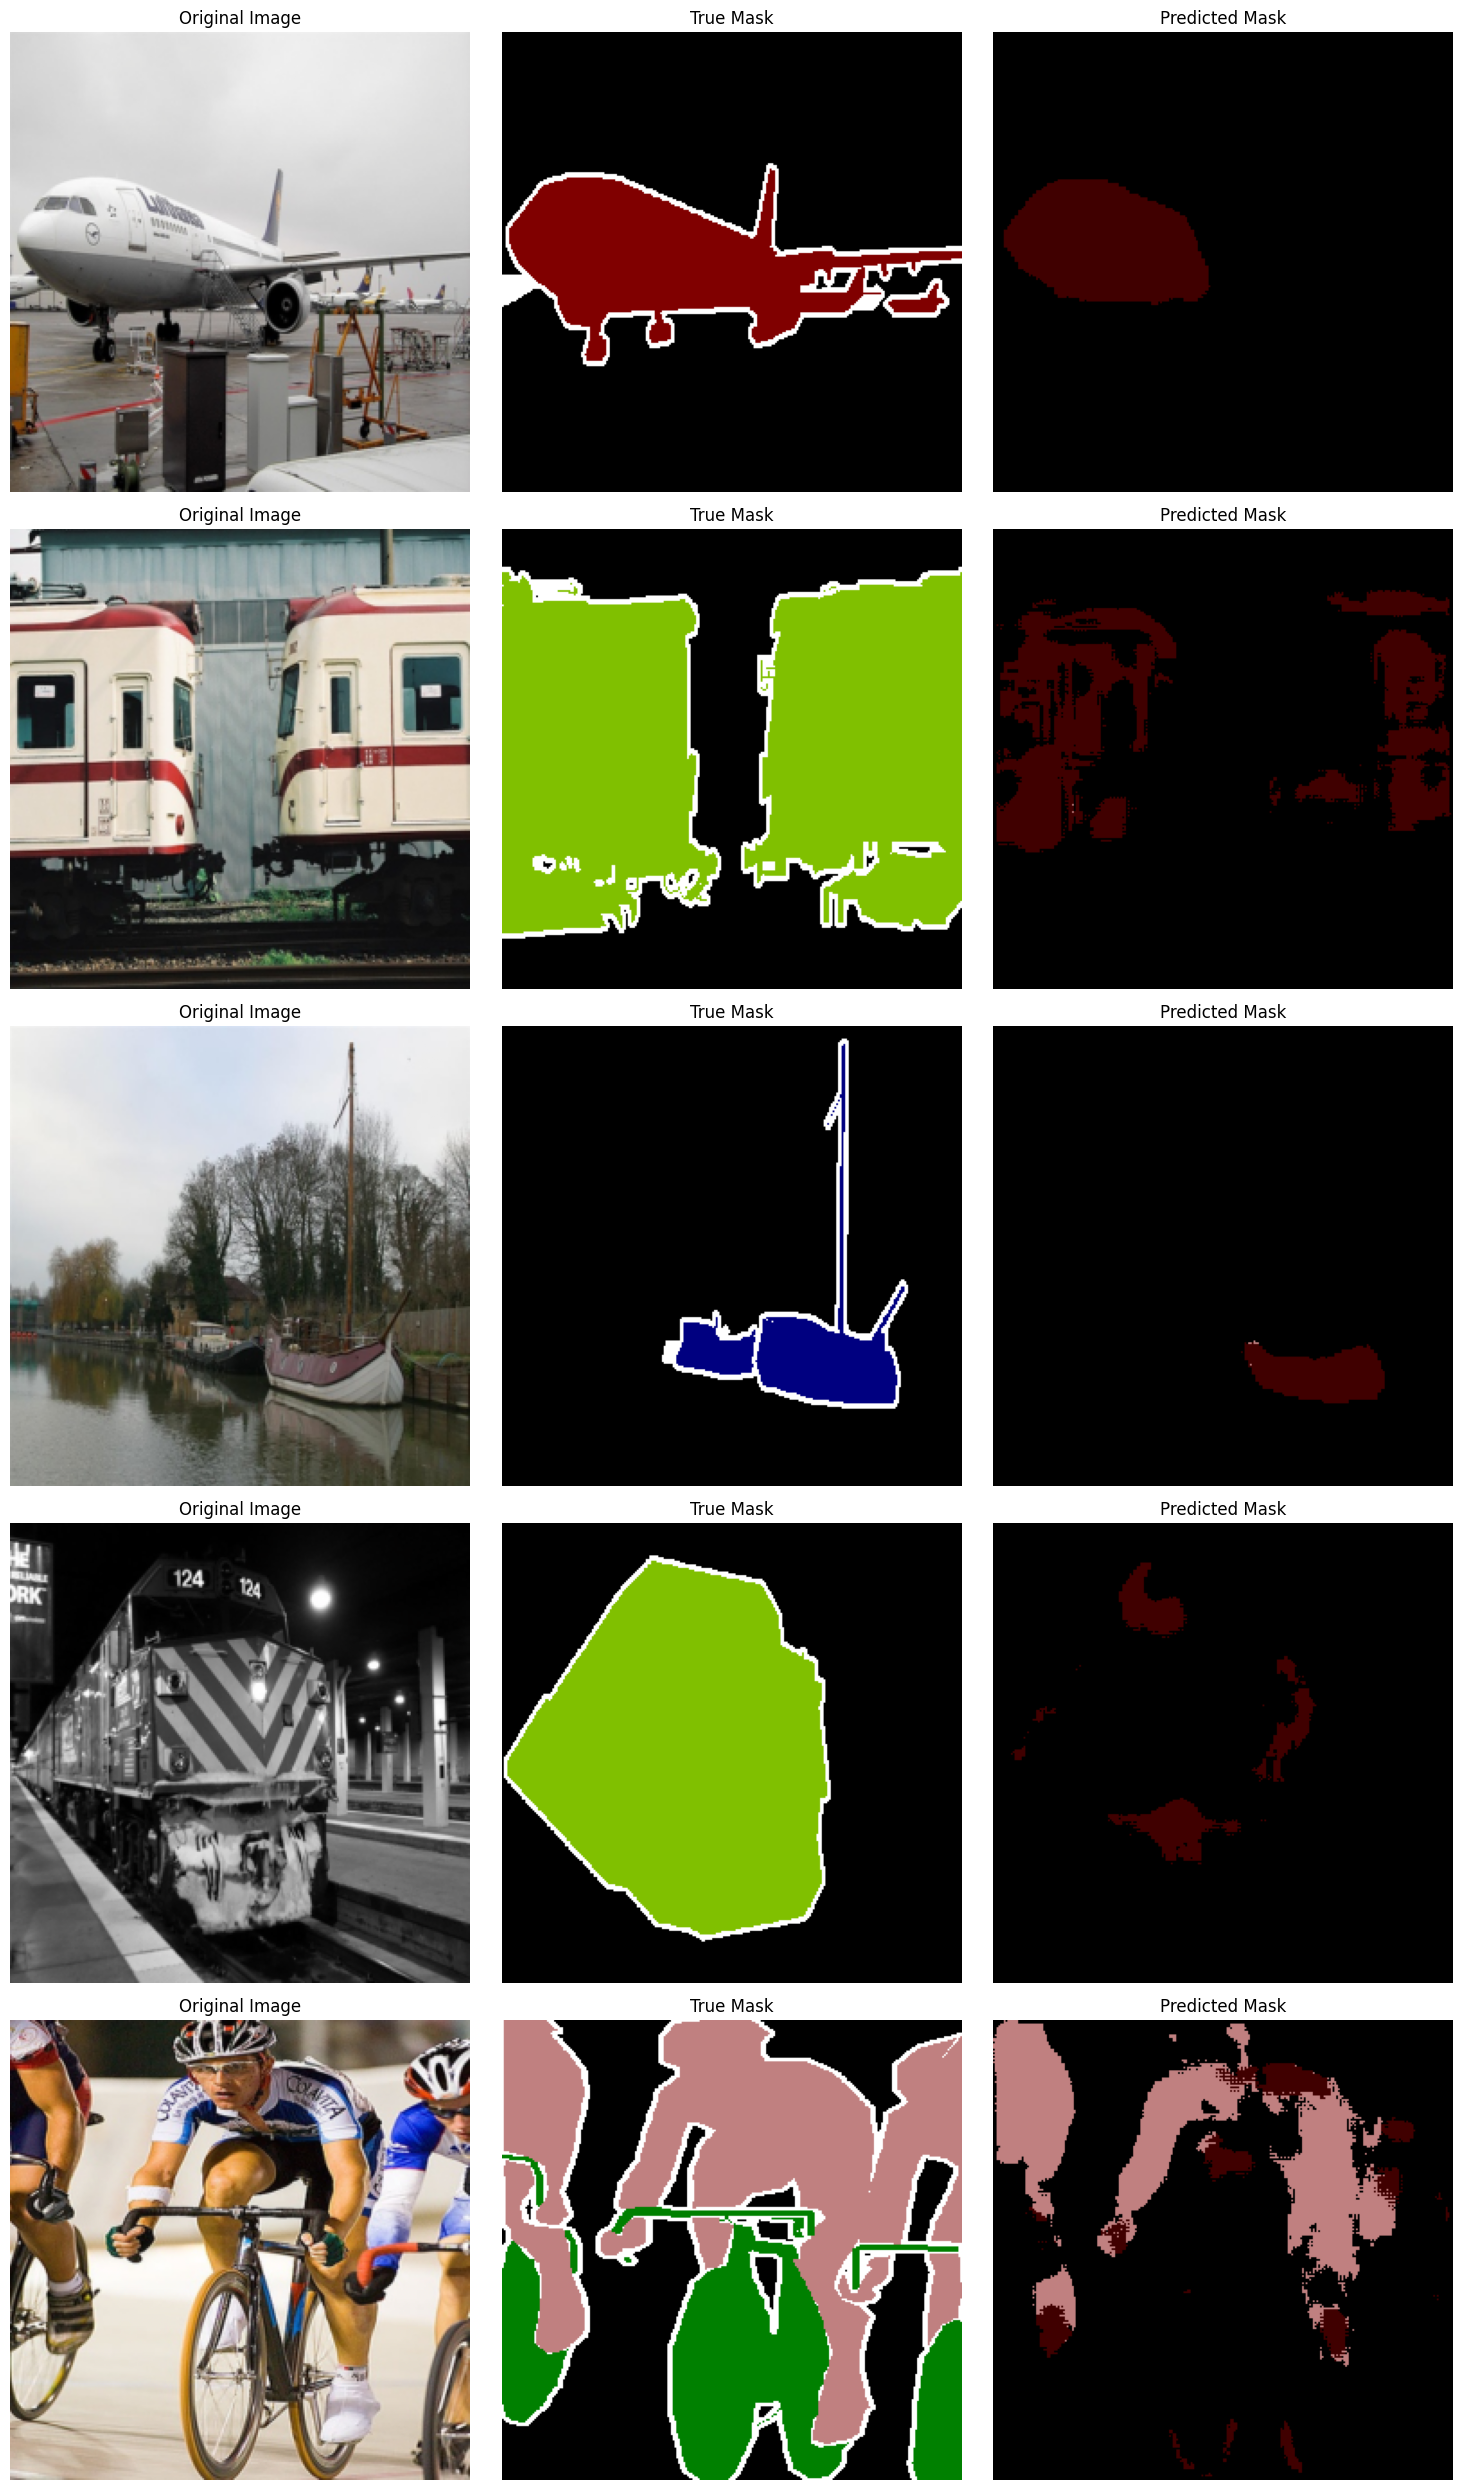

In [ ]:
# --- Функция для визуализации (без изменений) ---
voc_colormap = np.array([
    [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128],
    [128, 0, 128], [0, 128, 128], [128, 128, 128], [64, 0, 0], [192, 0, 0],
    [64, 128, 0], [192, 128, 0], [64, 0, 128], [192, 0, 128], [64, 128, 128],
    [192, 128, 128], [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
    [0, 64, 128]
], dtype=np.uint8)

full_colormap = np.zeros((256, 3), dtype=np.uint8)
full_colormap[:len(voc_colormap)] = voc_colormap
full_colormap[IGNORE_INDEX] = [255, 255, 255] # Белый для игнорируемых пикселей

def denormalize(tensor, mean, std):
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    tensor = torch.clamp(tensor, 0, 1)
    return tensor

def visualize_predictions(model, dataloader, device, num_samples=5):
    model.eval()
    samples_shown = 0
    data_iter = iter(dataloader)
    plt.figure(figsize=(15, num_samples * 5))

    with torch.no_grad():
        while samples_shown < num_samples:
            try:
                images, true_masks = next(data_iter)
            except StopIteration:
                print("Reached end of dataloader.")
                break

            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu()

            images_cpu = images.cpu()
            true_masks_cpu = true_masks.cpu()

            for i in range(images.size(0)):
                if samples_shown >= num_samples: break

                img = images_cpu[i]
                true_mask = true_masks_cpu[i].numpy()
                pred_mask = preds[i].numpy()

                img_denorm = denormalize(img, imagenet_mean, imagenet_std)
                img_np = img_denorm.permute(1, 2, 0).numpy()

                true_mask_rgb = full_colormap[true_mask]
                pred_mask_rgb = full_colormap[pred_mask]

                plt.subplot(num_samples, 3, samples_shown * 3 + 1)
                plt.imshow(img_np)
                plt.title("Original Image")
                plt.axis('off')

                plt.subplot(num_samples, 3, samples_shown * 3 + 2)
                plt.imshow(true_mask_rgb)
                plt.title("True Mask")
                plt.axis('off')

                plt.subplot(num_samples, 3, samples_shown * 3 + 3)
                plt.imshow(pred_mask_rgb)
                plt.title("Predicted Mask")
                plt.axis('off')

                samples_shown += 1

    plt.tight_layout()
    plt.show()

# --- Запуск Визуализации ---
print("\nVisualizing results for ResNet-UNet on validation set...")
visualize_predictions(model, val_loader, device, num_samples=5)

# Задача 3

Реализуйте семантическую сегментацию на предобученной Yolo

In [20]:
pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 827.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 73.2 MB/s eta 0:00:00


In [21]:
import os
from ultralytics import YOLO
import cv2

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Image 'image.jpg' not found. Downloading a sample image...


100%|██████████| 134k/134k [00:00<00:00, 30.8MB/s]

Sample image downloaded.
Loading YOLOv8 segmentation model: yolov8n-seg.pt...



100%|██████████| 6.74M/6.74M [00:00<00:00, 346MB/s]


Model loaded successfully.
Running inference on: image.jpg

image 1/1 /content/image.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 137.0ms
Speed: 16.4ms preprocess, 137.0ms inference, 490.5ms postprocess per image at shape (1, 3, 640, 480)
Inference complete.
Plotting results using ultralytics built-in plot function...


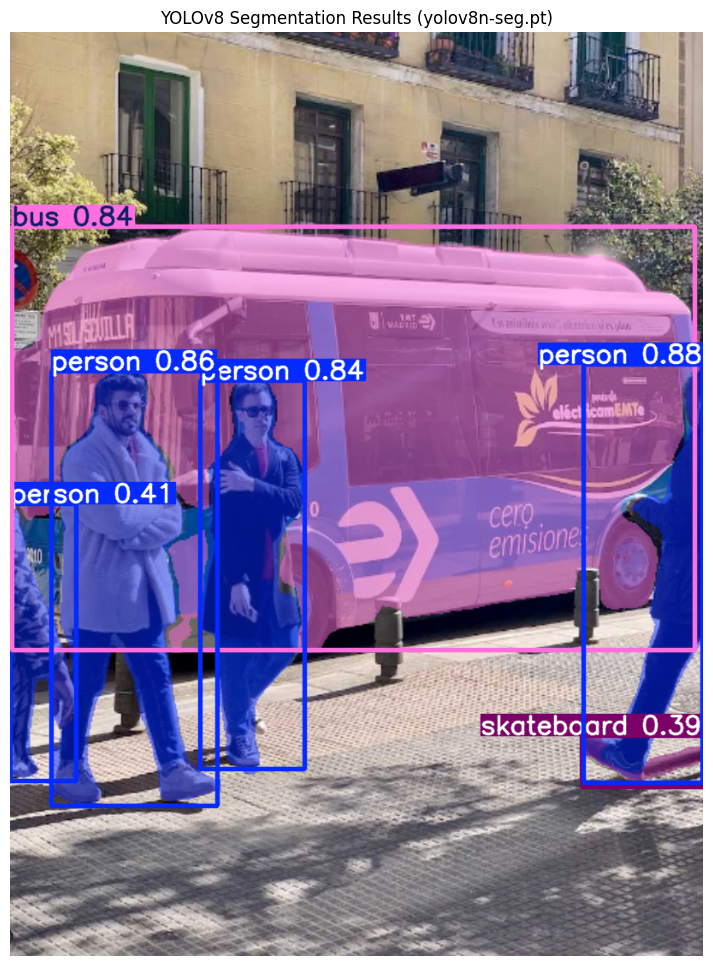


Manually overlaying masks (optional example)...


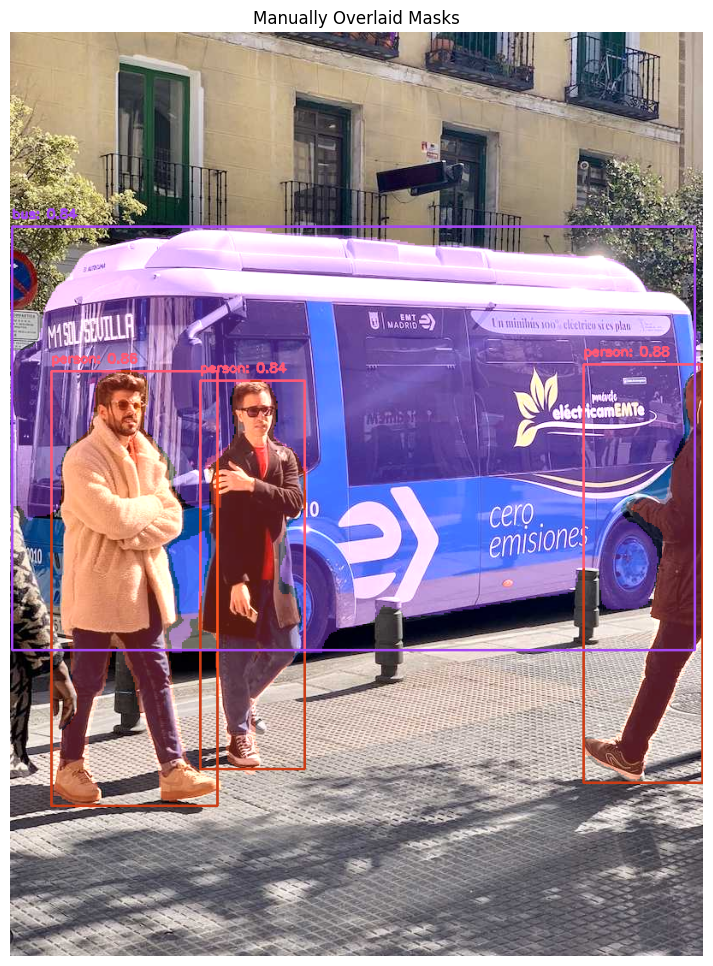

In [ ]:
MODEL_NAME = 'yolov8n-seg.pt'
IMAGE_PATH = 'image.jpg'

# Создайте пример изображения, если у вас нет своего
if not os.path.exists(IMAGE_PATH):
    try:
        print(f"Image '{IMAGE_PATH}' not found. Downloading a sample image...")
        torch.hub.download_url_to_file('https://ultralytics.com/images/bus.jpg', IMAGE_PATH)
        print("Sample image downloaded.")
    except Exception as e:
        print(f"Could not download sample image: {e}")
        print("Please provide a valid IMAGE_PATH.")
        img_placeholder = Image.new('RGB', (640, 480), color = 'grey')
        img_placeholder.save(IMAGE_PATH)
        print("Created a placeholder grey image.")


# --- Загрузка модели ---
try:
    print(f"Loading YOLOv8 segmentation model: {MODEL_NAME}...")
    model = YOLO(MODEL_NAME)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    print("Ensure you have internet connection for the first download.")
    exit()

# --- Выполнение предсказания ---
print(f"Running inference on: {IMAGE_PATH}")
try:
    results = model(IMAGE_PATH) # Список результатов (обычно один для одного изображения)
    print("Inference complete.")
except Exception as e:
    print(f"Error during inference: {e}")
    exit()

# --- Обработка и Визуализация Результатов ---
if results and results[0].masks is not None:
    print("Plotting results using ultralytics built-in plot function...")
    im_array = results[0].plot(conf=0.5) # Порог уверенности можно настроить
    im = Image.fromarray(im_array[..., ::-1]) # Конвертация BGR (cv2) в RGB (PIL)

    # Отображение с помощью Matplotlib
    plt.figure(figsize=(12, 12))
    plt.imshow(im)
    plt.title(f"YOLOv8 Segmentation Results ({MODEL_NAME})")
    plt.axis('off')
    plt.show()

    print("\nManually overlaying masks (optional example)...")
    # Загружаем оригинальное изображение с помощью OpenCV
    original_img_cv = cv2.imread(IMAGE_PATH)
    if original_img_cv is None:
        print(f"Error reading image with OpenCV: {IMAGE_PATH}")
    else:
        overlay = original_img_cv.copy()
        h, w = original_img_cv.shape[:2]

        # Получаем маски и классы из результатов
        masks = results[0].masks.data.cpu().numpy() # [N, H, W] - N масок
        boxes = results[0].boxes.data.cpu().numpy() # [N, 6] - x1, y1, x2, y2, conf, class_id

        # Создаем цветовую палитру (можно использовать свою)
        rng = np.random.default_rng(3) # Фиксируем seed для повторяемости цветов
        colors = rng.uniform(0, 255, size=(len(model.names), 3)).astype(np.uint8)

        for i, mask_data in enumerate(masks):
            class_id = int(boxes[i, 5])
            confidence = boxes[i, 4]

            if confidence > 0.5: # Порог уверенности
                # Масштабируем маску до оригинального размера изображения
                mask_resized = cv2.resize(mask_data, (w, h), interpolation=cv2.INTER_NEAREST)

                # Находим контуры маски (опционально, для рисования контура)
                # contours, _ = cv2.findContours(mask_resized.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

                # Получаем цвет для текущего класса
                color = colors[class_id].tolist() # Конвертируем в list для cv2

                # Создаем цветную маску
                colored_mask = np.zeros_like(original_img_cv, dtype=np.uint8)
                colored_mask[mask_resized > 0.5] = color # Заливаем пиксели маски цветом (>0.5 т.к. маски могут быть не бинарными)

                # Накладываем цветную маску на изображение с прозрачностью
                alpha = 0.4 # Прозрачность
                overlay = cv2.addWeighted(overlay, 1, colored_mask, alpha, 0)

                # Рисуем контур маски (опционально)
                # cv2.drawContours(overlay, contours, -1, color, 2) # Рисуем контур

                # Рисуем bounding box и текст (опционально)
                x1, y1, x2, y2 = boxes[i, :4].astype(int)
                label = f"{model.names[class_id]}: {confidence:.2f}"
                cv2.rectangle(overlay, (x1, y1), (x2, y2), color, 2)
                cv2.putText(overlay, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)


        # Отображаем результат ручного наложения
        plt.figure(figsize=(12, 12))
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.title("Manually Overlaid Masks")
        plt.axis('off')
        plt.show()


elif results:
     print("No masks found in the results.")
     results[0].show() # Покажет bounding boxes, если они есть
else:
    print("Inference failed, no results.")